In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns

# import own modules
_repo_name = "ofdma-spectrum-anomalies-simulation"
_module_path = os.getcwd()[: os.getcwd().find(_repo_name) + len(_repo_name)]
sys.path.append(os.path.join(os.path.abspath(_module_path), "src"))

from utils.data_utils import get_datapath

# some parameters and configuration for figures
COL_WIDTH = 3.5 # in inches
TWO_COL_WIDTH = 7.16 # in inches
RATIO = 1.618 # golden ratio
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 8

figure_path = os.path.join("..", "figures")

In [ ]:
DATASET_NR = 0

datapath = get_datapath(_repo_name)
datapath = os.path.join(datapath, str(DATASET_NR))

min_max = pd.read_csv(os.path.join(datapath, "spectrogram_min_max.csv"))
min_val = min_max["min_val"].values[0]
max_val = min_max["max_val"].values[0]

labels = pd.read_csv(os.path.join(datapath, "labels.csv"))
labels

,jammer_type,jammer_power,jammer_location,num_legitimate_transmitters,snr_by_su_0,snr_by_su_1,snr_by_su_2,snr_by_su_3,snr_by_su_4,snr_by_su_5,...,sjr_by_su_11,sjr_by_su_12,sjr_by_su_13,sjr_by_su_14,sjr_by_su_15,sjr_by_su_16,sjr_by_su_17,sjr_by_su_18,sjr_by_su_19,sjr_by_su_20
0,no jammer,NaN,NaN,7,11.205190,36.394835,28.633557,32.830631,27.876210,28.368506,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
1,no jammer,NaN,NaN,10,37.181006,27.196118,26.667923,26.924856,31.292516,23.784618,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
2,no jammer,NaN,NaN,4,16.792065,1.658751,15.343251,18.833420,28.515733,24.952806,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
3,no jammer,NaN,NaN,3,8.612550,20.931185,15.208468,24.046144,23.241120,4.563992,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
4,no jammer,NaN,NaN,6,23.530386,27.329550,20.605191,34.162754,28.238471,28.724330,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,random_hop,30.0,[35.51274735 19.92471911 1.5 ],3,47.406463,23.909494,11.627974,20.348687,16.331165,18.177022,...,-11.077470,1.883115,-6.844181,4.848347,-10.239276,-14.790576,-7.134045,-12.401833,-4.683988,-0.979003
19996,random_hop,20.0,[12.43643717 33.69950206 1.5 ],7,27.724150,30.047037,32.080249,28.966197,28.519574,39.414356,...,9.144673,4.178095,1.110013,-3.856498,7.007394,6.129318,-9.036473,-2.747978,-8.603953,-7.914939
19997,random_hop,25.0,[27.04544549 24.729692 1.5 ],6,33.530590,21.523479,25.318172,22.280053,10.522822,29.939076,...,17.265862,0.561977,6.202771,10.222053,0.146705,-9.631842,-10.114241,10.677068,-4.634555,-2.471883
19998,random_hop,10.0,[0.85910261 9.04560102 1.5 ],5,28.869627,27.791972,18.966235,9.829562,14.671112,19.737416,...,53.275415,-2.567677,6.091866,17.360764,10.718381,11.890497,17.143208,10.800973,25.274579,10.850180


In [3]:
labels["jammer_type"].value_counts()

jammer_type
no jammer     10000
deceptive      2000
sweep          2000
barrage        2000
pilot          2000
random_hop     2000
Name: count, dtype: int64

In [4]:
labels["jammer_power"].value_counts()

jammer_power
0.0     1462
15.0    1459
30.0    1452
20.0    1445
10.0    1411
5.0     1395
25.0    1376
Name: count, dtype: int64

Mean SNR: 24.82 dB, Std SNR: 7.18 dB
Mean SJR: 14.65 dB, Std SJR: 18.10 dB


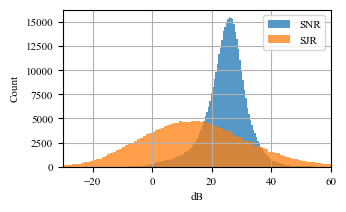

In [5]:
# analyze snr and sjr
def aggregate_over_sus(df, measure):
    all_vals = []
    for col in df.columns:
        if col.startswith(measure):
            vals = df[col].values
            vals = vals[np.isfinite(vals)]  # Filter out inf values of unjammed samples for SJR
            all_vals.extend(vals)

    return np.array(all_vals)

snr_values = aggregate_over_sus(labels, "snr")
print(f"Mean SNR: {np.mean(snr_values):.2f} dB, Std SNR: {np.std(snr_values):.2f} dB")
sjr_values = aggregate_over_sus(labels, "sjr")
print(f"Mean SJR: {np.mean(sjr_values):.2f} dB, Std SJR: {np.std(sjr_values):.2f} dB")

fig, ax = plt.subplots(figsize=(COL_WIDTH, COL_WIDTH/RATIO))
sns.histplot(snr_values, label="SNR", linewidth=0, binwidth=0.5)
sns.histplot(sjr_values, label="SJR", linewidth=0, binwidth=1.0)
plt.xlabel("dB")
# plt.title("Distribution of SNR and SJR")
plt.xlim(-30, 60)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "snr_sjr_distribution.pdf"))

In [6]:
def get_filename(sample_idx, su_idx):
    return os.path.join(datapath, "images", f"spectrogram-{str(sample_idx).zfill(5)}-{str(su_idx).zfill(2)}.png")

example_anomaly_types = {
    "deceptive": (10000, 2),
    "sweep": (12006, 19),
    "barrage": (14000, 4),
    "pilot": (16002, 16),
    "random_hop": (18001, 16)
}

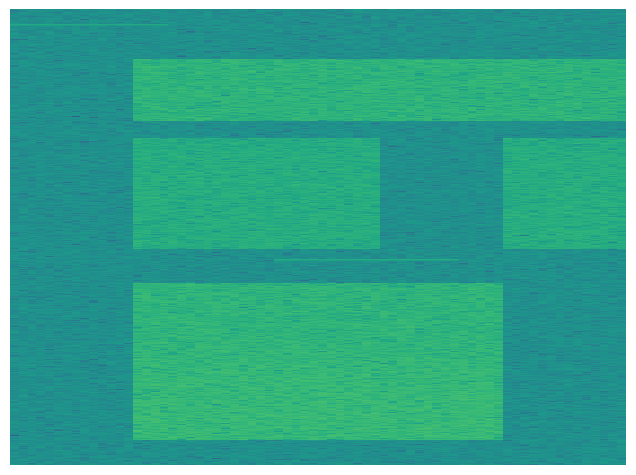

In [7]:
with_labels = False
save_fig = True
plot_type = "random_hop"  # either jammer types or "custom" sample and SU index shall be set manually
normalized_to_dataset = True

if plot_type in example_anomaly_types:
    sample_idx = example_anomaly_types[plot_type][0]
    su_idx = example_anomaly_types[plot_type][1]
else:
    sample_idx = 18001
    su_idx = 16

if normalized_to_dataset:
    c_min_val = min_val
    c_max_val = max_val
else:
    c_min_val = None
    c_max_val = None

img = Image.open(get_filename(sample_idx, su_idx))
img = np.array(img)/255.0 * (max_val - min_val) + min_val

fig, ax = plt.subplots()

if with_labels:
    sns.heatmap(img, cmap="viridis", cbar_kws={"label": "PSD [dBm/SC]"}, vmin=c_min_val, vmax=c_max_val)
    plt.title(
        f"Sample {sample_idx}, SU {su_idx}, jammer: {labels[f'jammer_type'].values[sample_idx]},\n"
        f"SNR: {labels[f'snr_by_su_{su_idx}'].values[sample_idx]:.2f} dB, SJR: {labels[f'sjr_by_su_{su_idx}'].values[sample_idx]:.2f} dB"
    )
    plt.xlabel("Symbol index")
    plt.ylabel("Subcarrier index")
else:
    plt.imshow(img, aspect="auto", origin="lower", cmap="viridis", interpolation="none", vmin=c_min_val, vmax=c_max_val)
    plt.axis("off")
plt.tight_layout()

if save_fig:

    if plot_type in example_anomaly_types:
        filename = f"example_{plot_type}_sample_{sample_idx}_su_{su_idx}"
    else:
        filename = f"sample_{sample_idx}_su_{su_idx}"

    if with_labels:
        filename += "_labeled"

    filename += ".pdf"

    plt.savefig(os.path.join(figure_path, filename), dpi=300, bbox_inches="tight")

<Axes: >

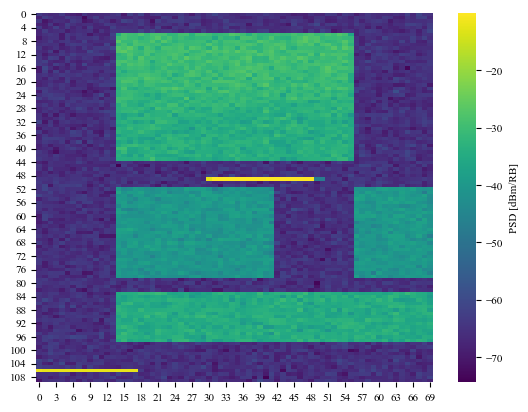

In [8]:
# reduce resolution by aggregating subcarriers
num_sc_per_rb = 12
def aggregate_subcarriers(spectrogram, num_sc_per_rb):
    num_rows, num_cols = spectrogram.shape
    num_aggregated_rows = num_rows // num_sc_per_rb
    aggregated_spectrogram = np.zeros((num_aggregated_rows, num_cols))

    for i in range(num_aggregated_rows):
        start_row = i * num_sc_per_rb
        end_row = start_row + num_sc_per_rb
        aggregated_spectrogram[i, :] = 10*np.log10(np.sum(10**(spectrogram[start_row:end_row, :] / 10), axis=0))

    return aggregated_spectrogram

sns.heatmap(aggregate_subcarriers(img, num_sc_per_rb), cmap="viridis", cbar_kws={"label": "PSD [dBm/RB]"})